# MSUP MCF + DPF Section Resultants — Method Walkthrough

**Reconstructing transient section forces and moments from a modal `.rst` and an MSUP `.mcf` — without ever writing a transient result file.**

This notebook walks through, step by step, what `scripts/mcf_dpf_section_resultants/gui.py` actually does, why it does it, and the structural-dynamics theory underneath. It is a self-contained companion to that tool and to its three Mechanical *"Get Solve Commands"* / *"On After Solve"* snippets.

### The problem in one line

A mode-superposition (MSUP) transient stores its response as **modal coordinates** $q_j(t)$. We want a **section force/moment resultant** $R(t)$ across a planar cut, *without* re-expanding the full transient result file:

$$ R(t) \;=\; \sum_{j} C_j \, q_j(t) $$

- $R(t)$ — the six-component section resultant $[F_x,F_y,F_z,\,M_x,M_y,M_z]$ at time $t$
- $q_j(t)$ — modal coordinate of mode $j$, read from the transient `file.mcf`
- $C_j$ — the **modal force/moment coefficient**: the section resultant that mode $j$ *alone* produces, computed once per mode from the modal `file.rst`

Because the internal section nodal forces are **linear** in displacement, the resultant inherits the same modal superposition as the displacement field — so an entire transient collapses to one cheap matrix–vector product.

### What is runnable here

The single step that needs a live DPF server and a solved `file.rst` — the `force_summation` operator that produces $C_j$ — is shown as an **annotated excerpt of the real tool**. *Every other stage* (MCF parsing, the construction-surface cut, the superposition, the moment transfer, the unit handling, the CSV writer) runs here on **synthetic data by calling the tool's own functions**, so you see the genuine mechanics end to end with **no ANSYS installed**.

## 1 · The pipeline at a glance

`extract_section_resultants()` orchestrates nine stages. The expensive DPF work happens **once per mode** on the small modal RST; the per-time-step work is just arithmetic.

| # | Stage | Function | Runnable here? |
|---|-------|----------|----------------|
| 1 | Load modal-RST metadata (named selections, modal-set count, mesh unit, coordinate systems) | `load_modal_rst_metadata` | DPF — excerpt |
| 2 | Parse the transient MCF → $q_j(t)$ | `parse_mcf` | ✅ real function |
| 3 | Resolve the element named selection → element scoping | `resolve_element_named_selection_scoping` | DPF — excerpt |
| 4 | Construction-surface cut → cut elements + side nodes + moment-reference centroids | `construction_surface_scoping` | ✅ real function (fake-mesh shim) |
| 5 | Choose the moment-reference point | (config) | ✅ |
| 6 | `force_summation` per modal set → coefficients $C_j$ | `modal_force_moment_coefficients` | DPF — excerpt |
| 7 | Superpose $\sum_j C_j\,q_j(t)$ | `extract_section_resultants` | ✅ real arithmetic |
| 8 | Shift moment to the reference, rotate to the local frame | `resultant_about_reference`, `rotate_to_local` | ✅ real functions |
| 9 | Write CSV + summary JSON | `write_result_csv`, `write_summary` | ✅ real function |

## 2 · Upstream Mechanical setup

The reconstruction is fed by a **two-stage** Workbench project. Three command snippets (committed alongside the tool as `.txt` files) wire it up.

**Stage 1 — Modal analysis** (`"Get Solve Commands"`). Make the modal solve write the *elemental nodal forces* (`NLOAD`) and nodal solution (`NSOL`) for the section element/node set, and expand modes **with element results** so those forces exist per mode:

```apdl
cmsel,s,DENEME,elem                ! the section element named selection
cm,_section_elems,elem
nsle,s,1                           ! nodes attached to those elements
cm,_section_nodes,node
outres,erase
outres,all,none
outres,nsol,all,_section_nodes     ! nodal solution for the section nodes
outres,nload,all,_section_elems    ! ELEMENTAL NODAL FORCES  <-- what force_summation needs
mxpand,,,,yes,,no                  ! expand modes WITH element results (ELCALC = YES)
```

**Stage 2 — MSUP transient** (`"Get Solve Commands"`). Keep the modal-coordinate file, drop the transient RST:

```apdl
mcfopt,1                           ! write Jobname.mcf (modal coordinates q_j(t))
outres,erase
outres,all,none                    ! suppress the (huge) re-expanded transient RST
```

An optional **`"On After Solve"`** IronPython snippet performs the *same* reconstruction *inside* Mechanical using `mech_dpf` / `Ans.DataProcessing`. The standalone tool documented here is the offline twin of that callback — usable interactively (PyQt GUI) or as a headless `--cli` / Slurm post job.

## 3 · Theory primer — why a per-mode coefficient is enough

In mode superposition the transient displacement is a linear combination of mode shapes $\varphi_j$ weighted by the modal coordinates:

$$ u(t) \;=\; \sum_j \varphi_j\, q_j(t). $$

A **section resultant** is obtained by summing the internal nodal forces of the elements cut by a plane, over the nodes on one side of the cut (the free-body / `NFORCE` convention). Those internal nodal forces are a *linear* operator $\mathcal{L}$ acting on the displacement, so

$$ R(t) \;=\; \mathcal{L}\big(u(t)\big) \;=\; \mathcal{L}\!\Big(\sum_j \varphi_j\, q_j(t)\Big) \;=\; \sum_j \underbrace{\mathcal{L}(\varphi_j)}_{\textstyle C_j}\, q_j(t). $$

$C_j = \mathcal{L}(\varphi_j)$ is exactly the section force+moment produced by **mode $j$ at unit modal coordinate** — six numbers per mode. Stacking the $C_j$ as rows of a matrix $\mathbf{C}\in\mathbb{R}^{n\times 6}$ and the modal coordinates at time $t$ as a vector $\mathbf{q}(t)\in\mathbb{R}^{n}$:

$$ R(t) \;=\; \mathbf{q}(t)^{\mathsf T}\,\mathbf{C}. $$

So DPF `force_summation` runs **once per mode** to build $\mathbf{C}$; the time history is then a single matrix–vector product per time step. That is the entire idea — the rest is bookkeeping (the cut, the moment reference, the frame, the units).

In [1]:
# ? Runnable demo ? load the tool's REAL functions (cheap: heavy deps import lazily inside functions)
import os, sys, types, tempfile, importlib.util
import numpy as np
import matplotlib.pyplot as plt

# Locate the repo root by walking up from the notebook's folder.
TOOL = os.path.join("scripts", "mcf_dpf_section_resultants", "gui.py")
REPO_ROOT, here = None, os.getcwd()
for _ in range(6):
    if os.path.isfile(os.path.join(here, TOOL)):
        REPO_ROOT = here
        break
    here = os.path.dirname(here)
assert REPO_ROOT, "could not locate " + TOOL
sys.path.insert(0, REPO_ROOT)
from scripts.mcf_dpf_section_resultants import gui as M

rng = np.random.default_rng(20260628)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.35,
                     "axes.titleweight": "bold"})
print("Loaded:", "scripts.mcf_dpf_section_resultants.gui")
print("ansys.dpf.core importable in this kernel:", importlib.util.find_spec("ansys.dpf.core") is not None)


Loaded: scripts.mcf_dpf_section_resultants.gui
ansys.dpf.core importable in this kernel: True


## 4 · Stage A — parse the MCF (the modal coordinates $q_j(t)$)

The MSUP solve writes `Jobname.mcf`: a header line `Number of Modes : N`, a `Time   Coordinates` banner, then one record per time step holding `time` followed by the $N$ modal coordinates. With `MCFOPT` wrapping, a record can span several indented continuation lines; `parse_mcf` (via `_unwrap_mcf_lines`) rejoins them and validates the count.

Below we synthesise a tiny MCF (decaying modal sinusoids), write it to a temp file, and parse it with **the tool's real `parse_mcf`**.

time points : [0.0, 0.001, 0.002, 0.003, 0.004, 0.005]
modes/point : 3
round-trip error vs source q: 4.94656871019572e-10


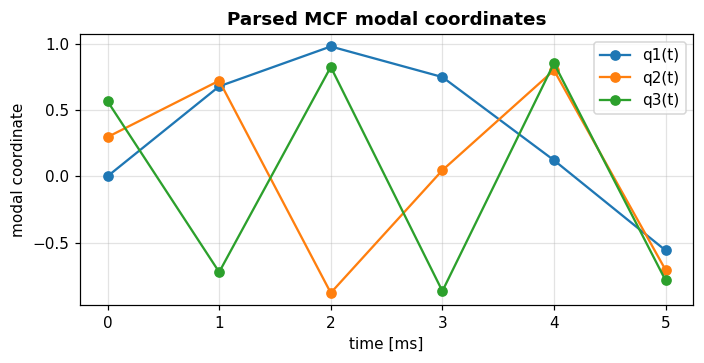


wrapped record -> 6 modal coordinates reassembled: [0.001, 0.002, 0.003, 0.004, 0.005, 0.006]


In [2]:
# ▶ Runnable demo — write a synthetic MCF and parse it with the REAL M.parse_mcf
n_modes = 3
t_grid = np.linspace(0.0, 5.0e-3, 6)
freqs, damp = [120.0, 320.0, 540.0], [10.0, 25.0, 40.0]
q_true = np.array([[np.exp(-damp[j] * t) * np.sin(2 * np.pi * freqs[j] * t + 0.3 * j)
                    for j in range(n_modes)] for t in t_grid])

lines = ["  Solution Set MCF dump (synthetic)", "  Number of Modes :   %d" % n_modes,
         "      Time                Coordinates"]
for t, row in zip(t_grid, q_true):
    lines.append("  %0.8E   " % t + "   ".join("%0.8E" % v for v in row))
mcf_path = os.path.join(tempfile.gettempdir(), "demo_walkthrough.mcf")
with open(mcf_path, "w", encoding="utf-8") as fh:
    fh.write("\n".join(lines) + "\n")

times, modal_coordinates = M.parse_mcf(mcf_path)
print("time points :", [round(t, 5) for t in times])
print("modes/point :", len(modal_coordinates[0]))
print("round-trip error vs source q:", float(np.max(np.abs(np.array(modal_coordinates) - q_true))))

fig, ax = plt.subplots(figsize=(7.2, 3.2))
for j in range(n_modes):
    ax.plot(np.array(times) * 1e3, [r[j] for r in modal_coordinates], "-o", label=f"q{j+1}(t)")
ax.set_xlabel("time [ms]"); ax.set_ylabel("modal coordinate"); ax.set_title("Parsed MCF modal coordinates")
ax.legend(); plt.show()

# MCFOPT line-wrapping: one record split across indented continuation lines is rejoined for us.
wrapped = ("  Number of Modes :   6\n      Time                Coordinates\n"
           "  0.00000000E+00   1.0E-03   2.0E-03   3.0E-03\n"
           "                   4.0E-03   5.0E-03   6.0E-03\n")
wp = os.path.join(tempfile.gettempdir(), "demo_wrapped.mcf")
open(wp, "w", encoding="utf-8").write(wrapped)
tw, qw = M.parse_mcf(wp)
print("\nwrapped record ->", len(qw[0]), "modal coordinates reassembled:", qw[0])

## 5 · Stage B — the construction-surface cut

`construction_surface_scoping` defines a plane through `origin` with a `normal` (a chosen local axis). For every element of the named selection it computes the **signed distance** of each node from the plane,

$$ d \;=\; (\mathbf{x}_{\text{node}} - \mathbf{x}_{\text{origin}})\cdot \mathbf{n}, $$

and classifies the element: if its nodes straddle the plane ($\min d \le \text{tol}$ **and** $\max d \ge -\text{tol}$) it is **cut**. For a positive-side probe, the cut elements' nodes with $d \ge -\text{tol}$ become the **side nodes** fed to `force_summation`. The function also returns three candidate **moment-reference centroids** (the selected-side nodes, the opposite-side nodes — matching Mechanical's probe convention — and a fallback).

We build a two-element hex column and call the **real function** through a minimal fake-`dpf`/fake-`mesh` shim. The frame is rotated 30° about $z$, so the cut is unchanged (the normal is still global $z$) but the in-plane local axes differ from global — useful later.

In [3]:
# ▶ Runnable demo — REAL construction_surface_scoping on a 2-hex column via a tiny shim
COORDS = {1: (0, 0, 0), 2: (1, 0, 0), 3: (1, 1, 0), 4: (0, 1, 0),
          5: (0, 0, 1), 6: (1, 0, 1), 7: (1, 1, 1), 8: (0, 1, 1),
          9: (0, 0, 2), 10: (1, 0, 2), 11: (1, 1, 2), 12: (0, 1, 2)}
ELEMS = {101: [1, 2, 3, 4, 5, 6, 7, 8], 102: [5, 6, 7, 8, 9, 10, 11, 12]}

class FakeScoping:                      # make_scoping() calls dpf.Scoping(ids=..., location=...)
    def __init__(self, ids=None, location=None):
        self.ids = [int(i) for i in (ids or [])]; self.location = location

fake_dpf = types.SimpleNamespace(
    Scoping=FakeScoping,
    locations=types.SimpleNamespace(elemental="Elemental", nodal="Nodal"))

class _N:  __init__ = lambda s, c: setattr(s, "coordinates", c)   # mesh.nodes.node_by_id(i).coordinates
class _E:  __init__ = lambda s, n: setattr(s, "node_ids", n)      # mesh.elements.element_by_id(i).node_ids
fake_mesh = types.SimpleNamespace(
    unit="mm",
    nodes=types.SimpleNamespace(node_by_id=lambda i: _N(COORDS[int(i)])),
    elements=types.SimpleNamespace(element_by_id=lambda i: _E(ELEMS[int(i)])))

c30, s30 = np.cos(np.deg2rad(30)), np.sin(np.deg2rad(30))
cfg = M.SectionConfig(
    coordinate_system_origin=[0.0, 0.0, 0.5],                 # plane at z = 0.5 (mid of the lower hex)
    coordinate_system_axes={"x": [c30, s30, 0], "y": [-s30, c30, 0], "z": [0, 0, 1]},
    section_normal_axis="z", extraction_side="positive",
    side_filter_tolerance=1e-9, moment_reference_mode="coordinate_system_origin")
axes = M.validate_axes(cfg.coordinate_system_axes)             # orthonormality check (det ~ +1)

elem_scope = M.make_scoping(fake_dpf, list(ELEMS), fake_dpf.locations.elemental)
filtered_elem_scope, node_scope, info = M.construction_surface_scoping(
    fake_dpf, None, elem_scope, cfg, axes, mesh=fake_mesh)

print("cut element(s)        :", M.object_ids(filtered_elem_scope))
print("selected side node(s) :", M.object_ids(node_scope))
print("positive / negative / on-plane node counts:",
      info["positive_node_count"], info["negative_node_count"], info["on_plane_node_count"])
print("selected-side centroid:", info["selected_node_centroid"])
print("moment-ref centroid   :", info["moment_reference_centroid"], "(", info["moment_reference_node_side"], ")")

cut element(s)        : [101]
selected side node(s) : [5, 6, 7, 8]
positive / negative / on-plane node counts: 4 4 0
selected-side centroid: [0.5, 0.5, 1.0]
moment-ref centroid   : [0.5, 0.5, 0.0] ( opposite_negative_for_positive_probe )


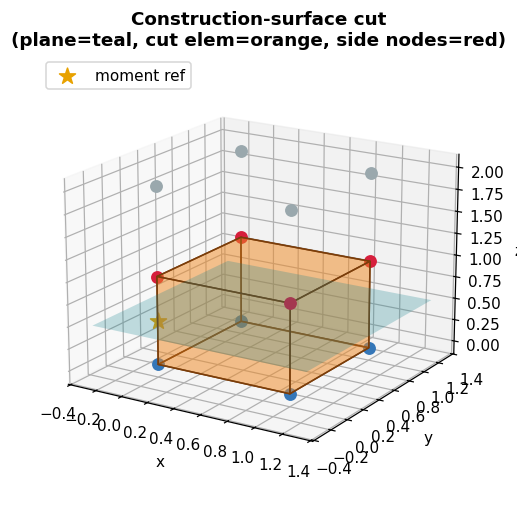

In [4]:
# ▶ Runnable demo — visualise the cut (same colours as the tool's PyVista viewer)
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
TEAL, CUT, SIDE, NEG, GOLD = "#18A8B8", "#F08A24", "#D61F3C", "#3577B8", "#E8A200"
sel = set(M.object_ids(node_scope)); cut = set(M.object_ids(filtered_elem_scope))

fig = plt.figure(figsize=(6.6, 5.2)); ax = fig.add_subplot(111, projection="3d")
# section plane at z = 0.5
xx, yy = np.meshgrid([-0.3, 1.3], [-0.3, 1.3])
ax.plot_surface(xx, yy, np.full_like(xx, 0.5), color=TEAL, alpha=0.25)
# cut element faces (element 101)
faces101 = [[1,2,3,4],[5,6,7,8],[1,2,6,5],[2,3,7,6],[3,4,8,7],[4,1,5,8]]
polys = [[COORDS[n] for n in f] for f in faces101]
ax.add_collection3d(Poly3DCollection(polys, facecolor=CUT, edgecolor="#7A3D0A", alpha=0.30))
# nodes coloured by role
for nid, xyz in COORDS.items():
    if nid in sel:        c, sname = SIDE, "side"
    elif nid in {1,2,3,4}: c, sname = NEG, "neg"
    else:                  c, sname = "#9aa8ad", "other"
    ax.scatter(*xyz, color=c, s=55, depthshade=False)
ax.scatter(*cfg.coordinate_system_origin, color=GOLD, s=120, marker="*", depthshade=False, label="moment ref")
ax.set_title("Construction-surface cut\n(plane=teal, cut elem=orange, side nodes=red)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z"); ax.legend(loc="upper left")
ax.view_init(elev=18, azim=-58); plt.show()

## 6 · Stage C — modal coefficients $C_j$ via DPF `force_summation`

For each modal set, the tool runs the DPF `force_summation` operator over the cut elements and the selected side nodes, and reads the accumulated force and moment fields. This is the **only** stage needing a live DPF server and a solved RST, so it is shown as an annotated excerpt (from `modal_force_moment_coefficients`):

```python
op = dpf.operators.averaging.force_summation()
connect_pin(op.inputs.data_sources, data_sources)
connect_pin(op.inputs.time_scoping, make_scoping(dpf, mode_ids))   # the modal sets in this batch
connect_pin(op.inputs.nodal_scoping, node_scope)                   # selected side nodes
connect_pin(op.inputs.elemental_scoping, filtered_elem_scope)      # cut elements
connect_pin(op.inputs.force_type, int(config.force_type))          # 1 static (default) / 0 total / 2 damp / 3 inertia
force_fc  = output_data(op.outputs.force_accumulation)
moment_fc = output_data(op.outputs.moment_accumulation)            # moment about the GLOBAL origin
# ... per mode: C_j = [Fx, Fy, Fz, Mx, My, Mz]
```

Two practical knobs live here:

- **`force_type`** selects the force family — `1` static (matches the Mechanical probe), `0` total (static+damping+inertia), `2` damping, `3` inertia. The damping/inertia families require that data to be present in the RST.
- **`modal_summation_batch_size`** (default 25) bounds how many modal sets go through `force_summation` at once, trading operator calls against peak memory on large models.

Below we stand in for the operator output with a synthetic $\mathbf{C}$ (one row per mode).

In [5]:
# ▶ Runnable demo — synthetic per-mode coefficients C (rows = modes, cols = [Fx,Fy,Fz,Mx,My,Mz] about global origin)
C = np.array([[ 600.0,  -40.0,  120.0,    0.0, 9000.0, -300.0],
              [ -80.0,  220.0,  -55.0,  500.0, -700.0,  140.0],
              [  35.0,  -18.0,  410.0, -120.0,  260.0, -900.0]])
import pandas as pd
display(pd.DataFrame(C, columns=["Fx", "Fy", "Fz", "Mx", "My", "Mz"],
                     index=[f"mode {j+1}" for j in range(len(C))]))

,Fx,Fy,Fz,Mx,My,Mz
mode 1,600.0,-40.0,120.0,0.0,9000.0,-300.0
mode 2,-80.0,220.0,-55.0,500.0,-700.0,140.0
mode 3,35.0,-18.0,410.0,-120.0,260.0,-900.0


## 7 · Stage D — superposition, moment transfer, and rotation to local

Now the cheap part. For each MCF row $\mathbf{q}(t)$ we form the resultant about the global origin, $\;g_c = \sum_j q_j\,C_{jc}\;$ for the six components $c$ — *this is exactly the loop in* `extract_section_resultants`. Then two real helpers finish the job:

- **Moment transfer** to the chosen reference point: `resultant_about_reference` applies $\;M_{\text{ref}} = M_O - \mathbf{ref}\times F\;$ (the force is unchanged).
- **Rotation to the local frame**: `rotate_to_local` projects $F$ and $M$ onto the coordinate-system axes by dot products.

Because our frame is rotated about $z$, the local $F_z$ equals the global $F_z$ (the normal is unchanged) while the in-plane components differ — a good sanity check that the rotation is doing something.

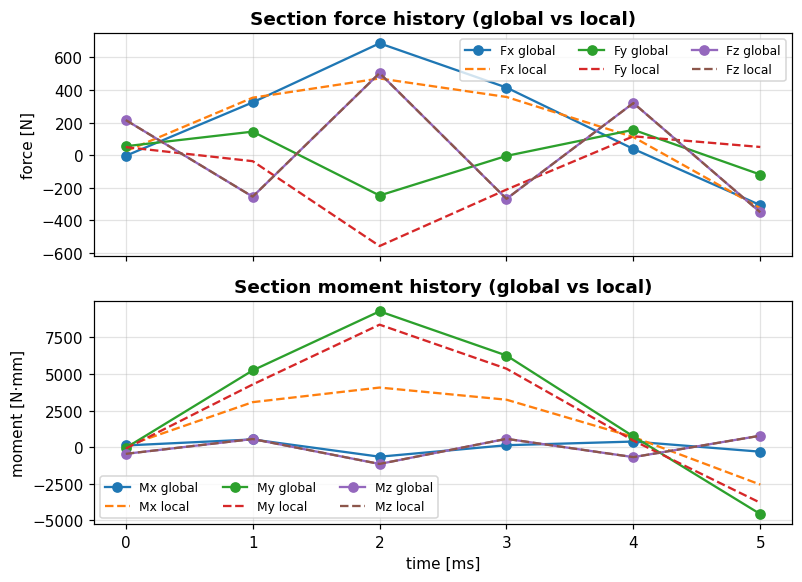

peak |component| (global): {'fx': 686.14, 'fy': 247.42, 'fz': 503.51, 'mx': 662.26, 'my': 9291.07, 'mz': 1158.01}


In [6]:
# ▶ Runnable demo — the REAL superposition (mirrors extract_section_resultants lines 3809-3826)
ref_xyz = [float(v) for v in cfg.coordinate_system_origin]    # moment reference = coordinate-system origin
n = min(len(C), len(modal_coordinates[0]))
res_global, res_local = [], []
for row in modal_coordinates:
    g = [sum(row[m] * C[m][c] for m in range(n)) for c in range(6)]   # sum_j q_j C_jc about global origin
    rg = M.resultant_about_reference(g, ref_xyz)                      # M_ref = M_O - ref x F
    res_global.append(rg)
    res_local.append(M.rotate_to_local(rg, axes))                    # project onto local axes
res_global, res_local = np.array(res_global), np.array(res_local)

tms = np.array(times) * 1e3
fig, (a1, a2) = plt.subplots(2, 1, figsize=(7.4, 5.4), sharex=True)
for k, lab in enumerate(["Fx", "Fy", "Fz"]):
    a1.plot(tms, res_global[:, k], "-o", label=f"{lab} global")
    a1.plot(tms, res_local[:, k], "--", label=f"{lab} local")
for k, lab in enumerate(["Mx", "My", "Mz"]):
    a2.plot(tms, res_global[:, 3 + k], "-o", label=f"{lab} global")
    a2.plot(tms, res_local[:, 3 + k], "--", label=f"{lab} local")
a1.set_ylabel("force [N]"); a1.set_title("Section force history (global vs local)"); a1.legend(ncol=3, fontsize=8)
a2.set_ylabel("moment [N·mm]"); a2.set_xlabel("time [ms]"); a2.set_title("Section moment history (global vs local)")
a2.legend(ncol=3, fontsize=8); plt.tight_layout(); plt.show()

print("peak |component| (global):", {k: round(v, 2) for k, v in M.max_abs_by_component(res_global.tolist()).items()})

## 8 · Units

DPF reports the **force** unit from the result field; the **moment** unit is inferred as *force × mesh-length* (e.g. `N` + `mm` → `N mm`). The GUI takes the origin in **millimetres** and converts it to the mesh's solver unit before any geometry test. The CSV column headers carry the resolved unit in brackets.

In [7]:
# ▶ Runnable demo — unit handling with the REAL helpers
print("infer_moment_unit('N', 'mm')              ->", M.infer_moment_unit("N", "mm"))
print("moment_unit_conversion_factor('N mm','N m')->", M.moment_unit_conversion_factor("N mm", "N m"))
print("length_unit_conversion_factor('mm','m')   ->", M.length_unit_conversion_factor("mm", "m"))

# origin entered in mm, mesh solved in m -> converted for DPF geometry:
cfg_m, conv = M.config_with_origin_in_mesh_units(
    M.SectionConfig(coordinate_system_origin=[51.0, 0.0, 0.0]), types.SimpleNamespace(unit="m"))
print("origin 51 mm -> mesh units:", cfg_m.coordinate_system_origin, "(factor", conv["factor"], conv["mesh_unit"] + ")")

infer_moment_unit('N', 'mm')              -> N mm
moment_unit_conversion_factor('N mm','N m')-> 0.001
length_unit_conversion_factor('mm','m')   -> 0.001
origin 51 mm -> mesh units: [0.051000000000000004, 0.0, 0.0] (factor 0.001 m)


## 9 · Output CSV

`write_result_csv` writes 13 columns — `time_s`, the global $F/M$, then the local $F/M$ — each labelled with its unit, and the moment columns named `*_about_moment_reference` to record the summation point. The write is atomic (temp file + `os.replace`) and refuses to clobber a CSV that is open/locked.

In [8]:
# ▶ Runnable demo — write the CSV with the REAL M.write_result_csv, then read it back
import pandas as pd
csv_path = os.path.join(tempfile.gettempdir(), "demo_section_resultants.csv")
M.write_result_csv(csv_path, times, res_global.tolist(), res_local.tolist(),
                   {"force": "N", "moment": "N mm"})
df = pd.read_csv(csv_path)
print("columns (%d):" % df.shape[1])
for col in df.columns:
    print("   ", col)
display(df.head(3))

columns (13):
    time_s
    fx_global [N]
    fy_global [N]
    fz_global [N]
    mx_global_about_moment_reference [N mm]
    my_global_about_moment_reference [N mm]
    mz_global_about_moment_reference [N mm]
    fx_local [N]
    fy_local [N]
    fz_local [N]
    mx_local_about_moment_reference [N mm]
    my_local_about_moment_reference [N mm]
    mz_local_about_moment_reference [N mm]


,time_s,fx_global [N],fy_global [N],fz_global [N],mx_global_about_moment_reference [N mm],my_global_about_moment_reference [N mm],mz_global_about_moment_reference [N mm],fx_local [N],fy_local [N],fz_local [N],mx_local_about_moment_reference [N mm],my_local_about_moment_reference [N mm],mz_local_about_moment_reference [N mm]
0,0.000,-3.879130,54.850881,215.249803,107.428447,-58.117537,-466.805397,24.066015,49.441821,215.249803,63.976996,-104.045487,-466.805397
1,0.001,323.720062,144.375976,-254.583055,519.083649,5245.622747,547.925597,352.537785,-36.826768,-254.583055,3072.351000,4283.300733,547.925597
2,0.002,686.142301,-247.423423,503.514557,-662.259378,9291.065165,-1158.010250,470.504952,-557.346121,503.514557,4071.999137,8377.428150,-1158.010250


## 10 · `skip_first_modes`, batching, and version gating

- **`skip_first_modes = N`** drops the first $N$ MCF modal-coordinate columns *and* the first $N$ RST modal-set IDs before summation — use it to discard rigid-body or otherwise unwanted leading modes, keeping the MCF columns and the RST coefficients aligned.
- **`modal_summation_batch_size`** chops the modal sets into batches through `force_summation`; lower it if a large modal RST hits memory-allocation errors.
- **Version gating** — for ANSYS 2022 R2 … 2023 R2 the tool requires `ansys-dpf-core < 0.16.0`; a preflight check (`preflight_dpf_open`) raises a clear `DpfCompatibilityError` with the exact install command, and `connect_optional_pin` tolerates pin-name differences across DPF releases.

## 11 · Run against your own solved `file.rst` + `file.mcf` *(optional)*

Everything above used synthetic inputs so the notebook runs anywhere. To reproduce a **real** extraction, set the two paths below to a solved modal RST (with `NLOAD`/`NSOL` output) and the matching transient MCF, with `ansys-dpf-core` installed. The cell is fully gated: with empty paths or no DPF it prints a skip message and does nothing.

In [9]:
# ▶ Runnable demo — gated real extraction (no-op unless you provide paths AND have ansys-dpf-core)
MODAL_RST = r""          # e.g. r"D:\\proj\\modal\\file.rst"
MCF       = r""          # e.g. r"D:\\proj\\transient\\file.mcf"
OUT_CSV   = os.path.join(tempfile.gettempdir(), "my_section_resultants.csv")

have_dpf = importlib.util.find_spec("ansys.dpf.core") is not None
if have_dpf and MODAL_RST and MCF and os.path.exists(MODAL_RST) and os.path.exists(MCF):
    real_cfg = M.SectionConfig(
        modal_rst=MODAL_RST, mcf=MCF, out_csv=OUT_CSV,
        element_named_selection="DENEME",
        coordinate_system_origin=[51.0, 0.0, 0.0], section_normal_axis="z",
        extraction_side="positive", moment_reference_mode="mechanical_probe_mesh_centroid",
        force_type=1)
    summary = M.extract_section_resultants(real_cfg, log=lambda m: print(m))
    print("\\nWrote:", summary["out_csv"], "| time points:", summary["time_point_count"],
          "| modes used:", summary["modes_used"])
    display(pd.read_csv(OUT_CSV).head())
else:
    print("Skipped real run — set MODAL_RST and MCF (and install ansys-dpf-core).")
    print("   ansys.dpf.core present:", have_dpf, "| paths set:", bool(MODAL_RST and MCF))

Skipped real run — set MODAL_RST and MCF (and install ansys-dpf-core).
   ansys.dpf.core present: True | paths set: False


## 12 · Limitations & validation

- **Linearity is the load-bearing assumption.** The superposition $R(t)=\sum_j C_j q_j(t)$ is exact for a linear MSUP recombination. Contact opening/closing, large deflection, or other nonlinearity in the *recombination* breaks it (the same caveat that applies to MSUP itself).
- **The RST must contain the right output** — `OUTRES,NLOAD` (elemental nodal forces) and `NSOL` for the section set, with `MXPAND,…,ELCALC=YES`. The damping/inertia `force_type` families additionally require those force contributions to be stored.
- **Mode alignment** — `skip_first_modes` must remove the *same* leading modes from the MCF columns and the RST modal sets; the tool warns and truncates if the two counts disagree.
- **Validation** — compare the CSV against a Mechanical **Construction Surface / Surface** probe with *Local Coord Summation*. Set `moment_reference_mode = "mechanical_probe_mesh_centroid"` to match the probe's centroid summation point; agreement should be to numerical precision.

---

*This notebook calls the production tool's own functions throughout (`parse_mcf`, `construction_surface_scoping`, `resultant_about_reference`, `rotate_to_local`, the unit helpers, `write_result_csv`) — so what you ran here is the same code path the GUI and the `--cli` batch job use.*